# This code is used to import the model and run the model.

In [25]:
%pip install torch==2.6.0
%pip install torchvision==0.21.0
%pip install numpy
%pip install matplotlib
%pip install tdqm
%pip install numpy==1.24.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.24.1.tar.gz (10.9 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [32 lines of output]
      Traceback (most recent call last):
        File "/Users/thomas/Documents/GitHub/CSE_144_Final_Project/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "/Users/thomas/Documents/GitHub/CSE_144_Final_Project/.venv/lib/python3.13/site-packages/pip/_vendor/pyproject_hooks

In [26]:
# Imports
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from torch.utils.data import Dataset, Subset
import json
import numpy as np
import matplotlib.pyplot as plt
import os
# from ipynb.fs.defs.final_project_V3 import RegNetHead

# Select the model file
* https://stackoverflow.com/questions/9319317/quick-and-easy-file-dialog-in-python/14119223#14119223

In [27]:
# root = tk.Tk()
# root.withdraw()

# model_path = filedialog.askopenfilename(title='Select Model')

# Select the test folder path
* https://stackoverflow.com/questions/50860640/ask-a-user-to-select-folder-to-read-the-files-in-python

In [28]:
# test_file_path = filedialog.askdirectory(title='Select Test Folder')

# Check is there any hardware acceleration

In [29]:
# https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)

mps


# Load the model
* https://pytorch.org/tutorials/beginner/saving_loading_models.html

In [30]:
# Define custom classification head
class RegNetHead(nn.Module):
    def __init__(self, in_features=3712, num_classes=100):  # Adjust `in_features` to match RegNet output
        super(RegNetHead, self).__init__()
         # self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            # nn.Linear(in_features, 1000),
            # nn.ReLU(),
            # nn.Linear(in_features, 1000),
            nn.Linear(in_features, num_classes),
            # nn.Softmax()  # Ensure softmax is applied along the correct dimension
        )

    def forward(self, x):
        # x = self.avgpool(x)
        return self.classifier(x)

# Load pretrained RegNet model
base_model = models.regnet_y_32gf(weights=models.RegNet_Y_32GF_Weights.IMAGENET1K_V2).to(device)

# Remove the original classifier (fc layer) and add our custom head
in_features: int = base_model.fc.in_features  # Get input features of last linear layer
base_model.fc = RegNetHead(in_features, num_classes=100).to(device)  # Replace with custom head

# Verify Model Architecture
print(base_model)

RegNet(
  (stem): SimpleStemIN(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (trunk_output): Sequential(
    (block1): AnyStage(
      (block1-0): ResBottleneckBlock(
        (proj): Conv2dNormActivation(
          (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(2, 2), bias=False)
          (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (f): BottleneckTransform(
          (a): Conv2dNormActivation(
            (0): Conv2d(32, 232, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(232, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (b): Conv2dNormActivation(
            (0): Conv2d(232, 232, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
            (1):

# Load weights

In [31]:
FILE_PATH: str = "./weights/20250310_044326.pth"

base_model.load_state_dict(torch.load(FILE_PATH, weights_only=True,map_location=torch.device(device)))

<All keys matched successfully>

# Transfrom image

In [32]:
transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
])

# Load test 

In [33]:
TEST_DIR_PATH: str = "./test"

dataset: datasets.ImageFolder = datasets.ImageFolder(TEST_DIR_PATH, transform=transform)
loader: DataLoader = DataLoader(dataset, shuffle=False)
filepaths = [sample[0] for sample in dataset.samples]

In [34]:
print(filepaths)

['./test/test/0.jpg', './test/test/1.jpg', './test/test/10.jpg', './test/test/100.jpg', './test/test/101.jpg', './test/test/102.jpg', './test/test/103.jpg', './test/test/104.jpg', './test/test/105.jpg', './test/test/106.jpg', './test/test/107.jpg', './test/test/108.jpg', './test/test/109.jpg', './test/test/11.jpg', './test/test/110.jpg', './test/test/111.jpg', './test/test/112.jpg', './test/test/113.jpg', './test/test/114.jpg', './test/test/115.jpg', './test/test/116.jpg', './test/test/117.jpg', './test/test/118.jpg', './test/test/119.jpg', './test/test/12.jpg', './test/test/120.jpg', './test/test/121.jpg', './test/test/122.jpg', './test/test/123.jpg', './test/test/124.jpg', './test/test/125.jpg', './test/test/126.jpg', './test/test/127.jpg', './test/test/128.jpg', './test/test/129.jpg', './test/test/13.jpg', './test/test/130.jpg', './test/test/131.jpg', './test/test/132.jpg', './test/test/133.jpg', './test/test/134.jpg', './test/test/135.jpg', './test/test/136.jpg', './test/test/137.j

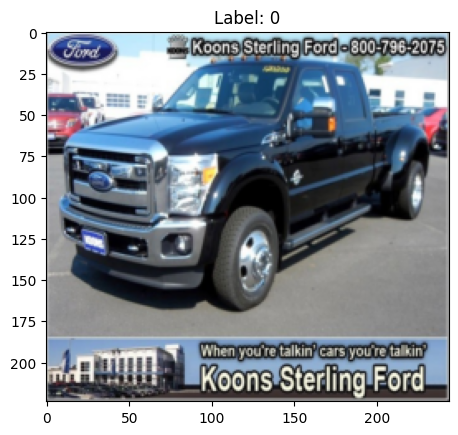

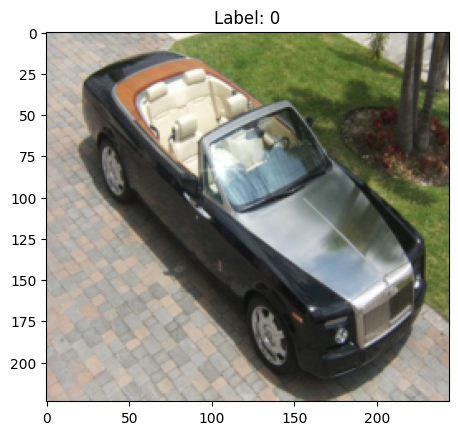

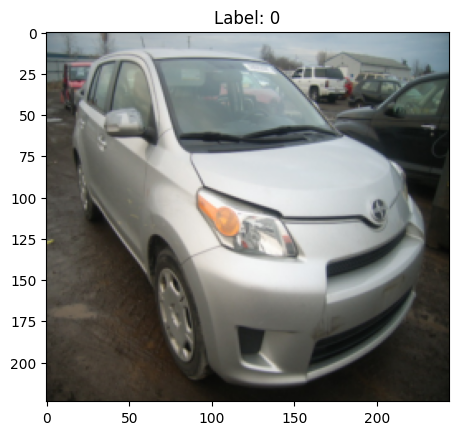

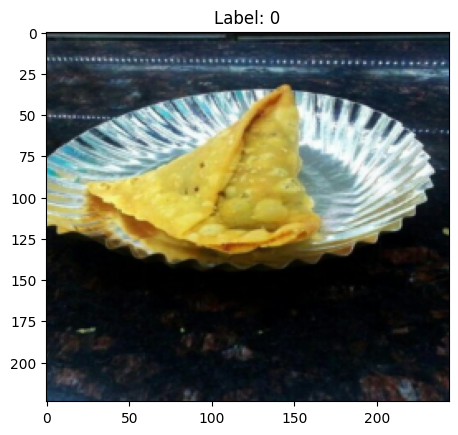

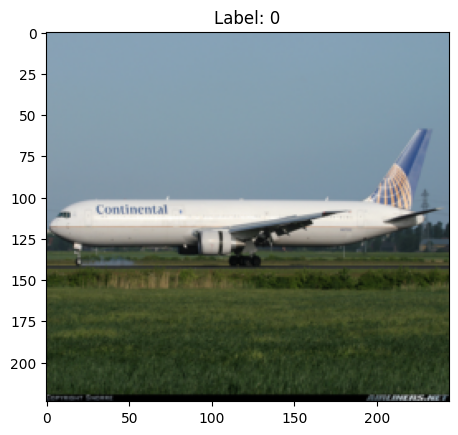

In [35]:
# print(dataset)
# print(loader)

def display_images(num_images):
    for i, (image, label) in enumerate(loader):
        if i >= num_images:
            break
        plt.imshow(image[0].permute(1, 2, 0))
        plt.title(f"Label: {label[0]}")
        plt.show()

# Example usage
display_images(5)


In [37]:
RESULT_CSV_PATH: str = "pumping_lemma_proof.csv"

with open(RESULT_CSV_PATH, 'w') as f:
    f.write("ID,Label\n")

i: int = 0
store_result: dict = {}
for data in loader:
    image, label = data
    image, label = image.to(device=device), label.to(device=device)
    with torch.no_grad():
        output = base_model(image)

    _, predicted = torch.max(output.data, 1)

    predicted: int = predicted.to('cpu').numpy()[0]
    store_result[os.path.basename(filepaths[i])] = predicted
    i += 1


for k in range(1000):
    with open(RESULT_CSV_PATH, 'a') as f:
        f.write(f"{k}.jpg,{store_result[str(k)+".jpg"]}\n")

# with open(RESULT_CSV_PATH, 'a') as f:
#     f.write(f"{i}.jpg,{predicted}\n")